In [7]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

## 1. Data Exploration & Preprocessing
In questa prima fase carichiamo il dataset 'Diabetes' e ne analizziamo la struttura. 
Utilizziamo `.describe()` per studiare la distribuzione statistica delle feature (media, deviazione standard, quartili). La matrice di scatter ci permette di identificare visivamente:
- La distribuzione delle singole variabili (es. presenza di asimmetrie o outlier).
- Eventuali forti correlazioni lineari tra le feature e tra le feature e il target (progressione della malattia).
Infine, separiamo i dati in Training Set (per l'addestramento e la validazione) e Test Set (tenuto rigorosamente da parte per la valutazione finale).

In [8]:
data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

x = df.drop(columns=['target'])
y = df['target']

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [9]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


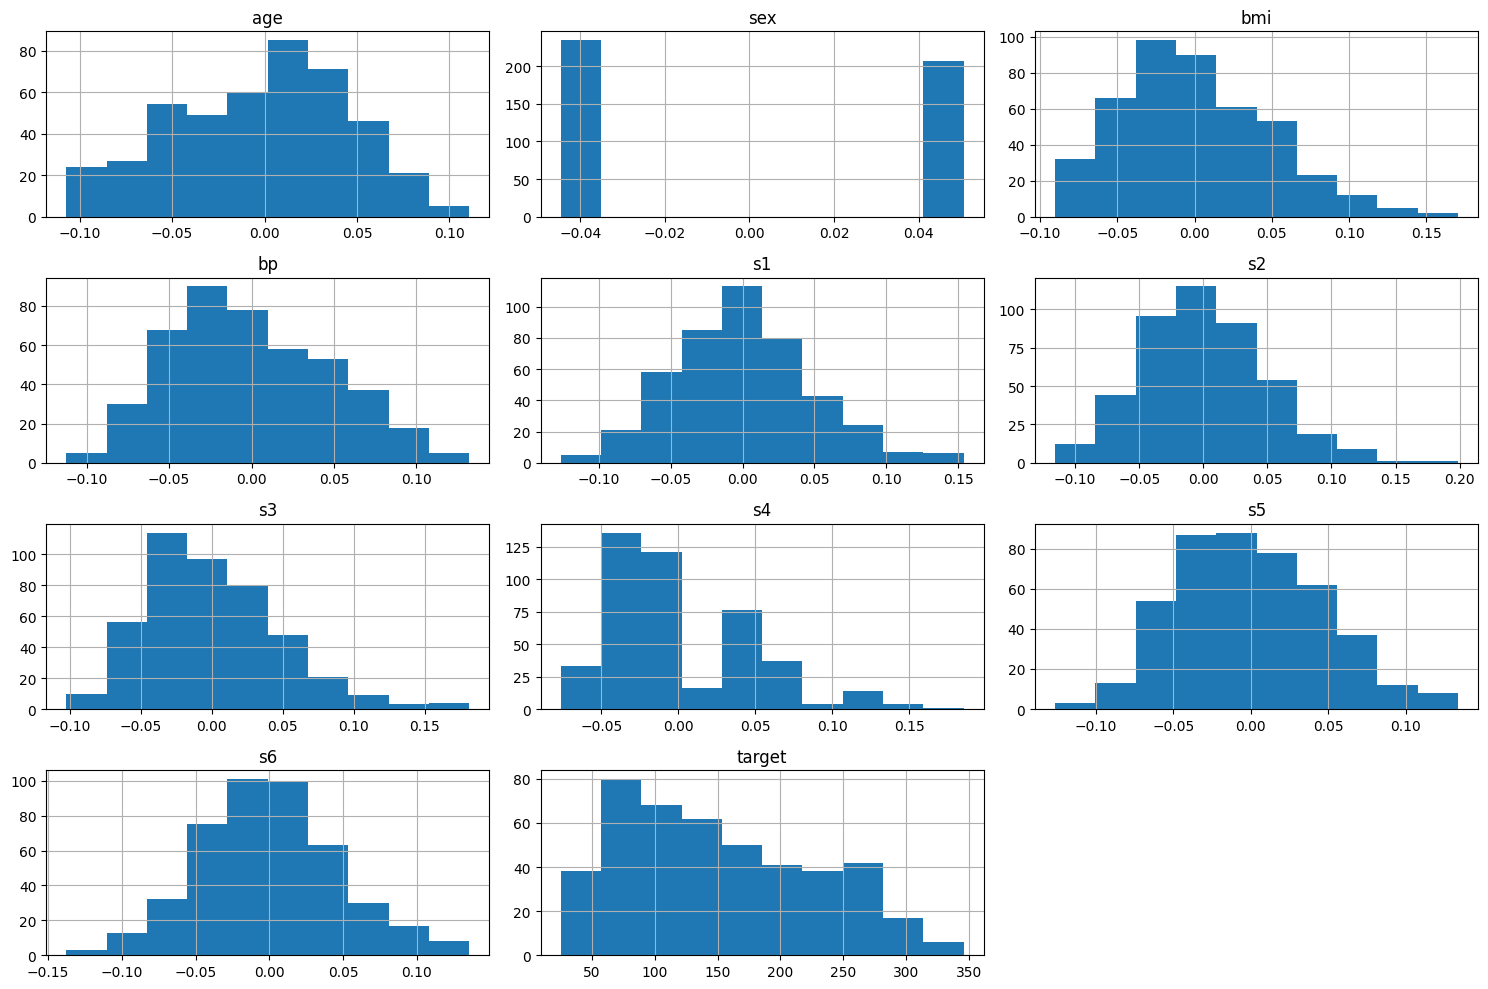

In [11]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

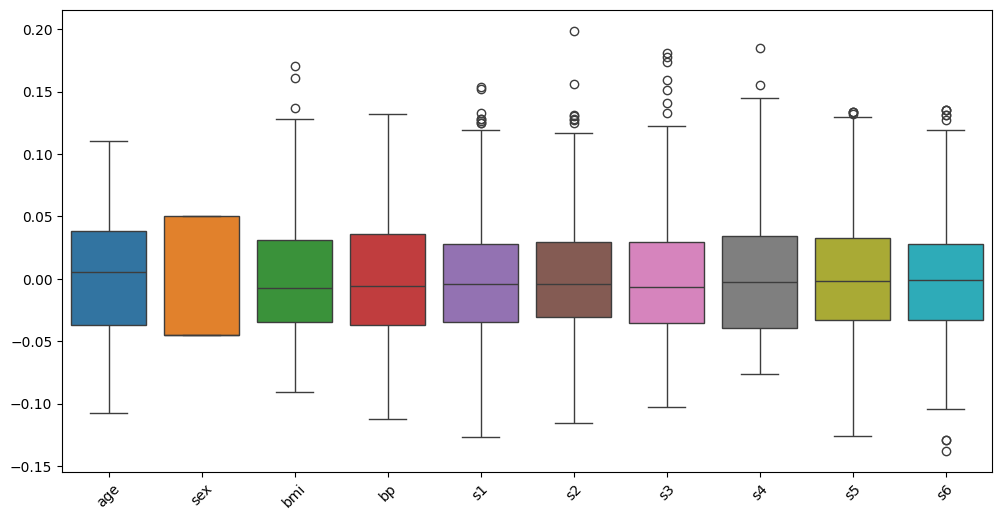

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=x)
plt.xticks(rotation=45)
plt.show()

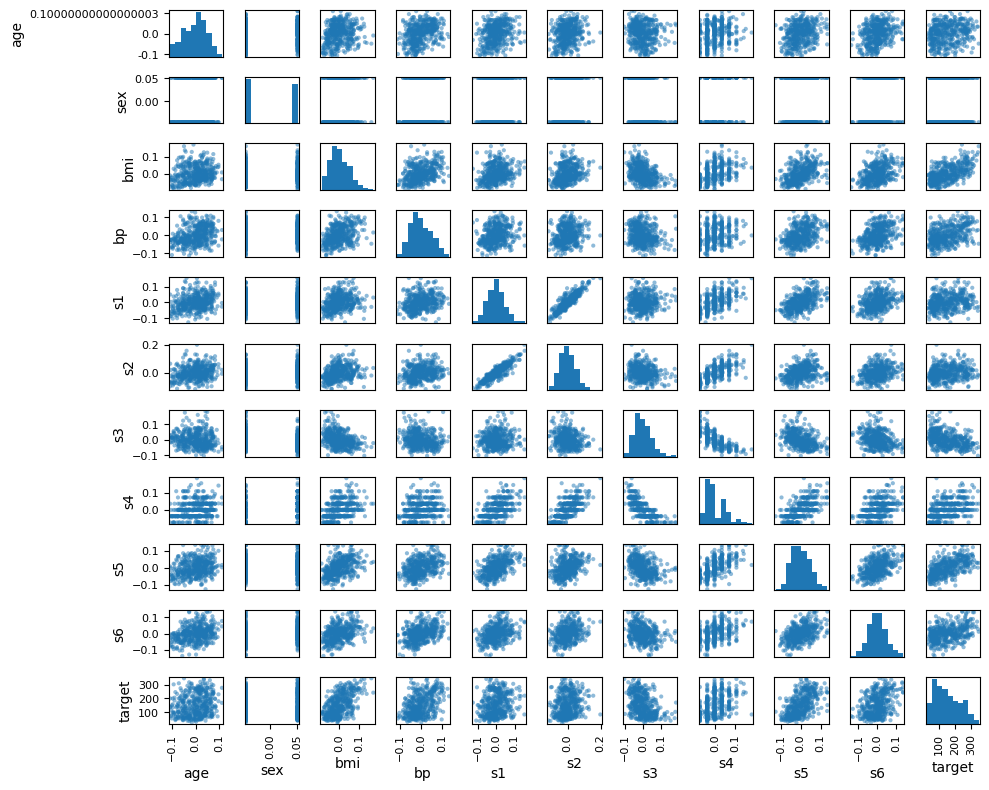

In [13]:
scatter_matrix(df, figsize=(10,8))
plt.tight_layout()
plt.show()

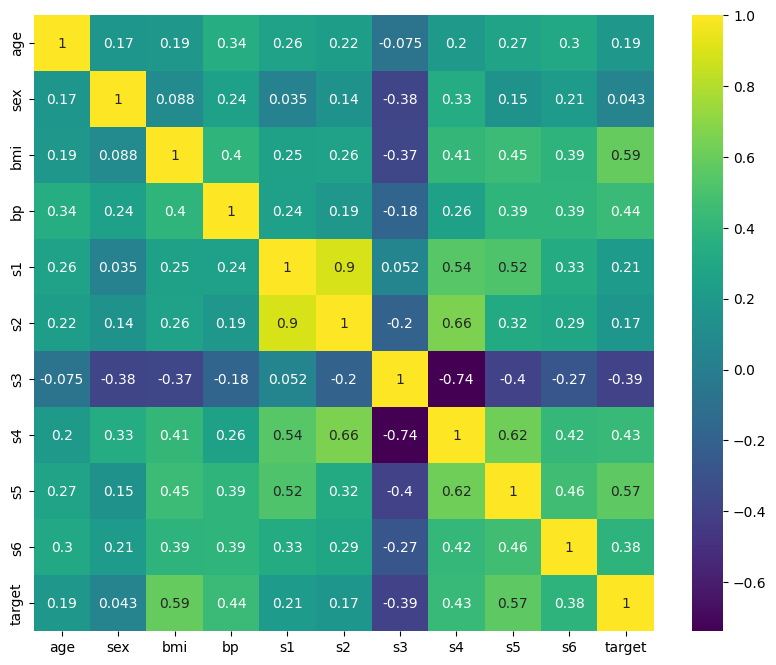

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.show()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)


In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"\nDimensioni del Train set: {x_train_scaled.shape}")
print(f"Dimensioni del Test set: {x_test_scaled.shape}")


Dimensioni del Train set: (353, 10)
Dimensioni del Test set: (89, 10)


## 2. Confronto e Selezione Iniziale dei Modelli
Per individuare l'algoritmo più promettente, implementiamo una baseline confrontando sei diversi modelli (lineari, non lineari e basati su alberi).
Per evitare il 'data leakage' e avere una stima robusta della capacità di generalizzazione, utilizziamo la **K-Fold Cross-Validation** (con metriche basate su NMSE). 
L'NMSE (Negative Mean Squared Error) è scelto come da specifiche della comanda: un valore più vicino a zero indica un errore inferiore e quindi un modello migliore.

In [17]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree' : DecisionTreeRegressor(random_state=42),
    'Ridge' : Ridge(),
    'Lasso' : Lasso(),
    'KNN' : KNeighborsRegressor(),
    'SVR' : SVR()
}

In [18]:
kfold = KFold( n_splits=5, shuffle=True, random_state=42)

results = {}

In [19]:
for name, model in models.items():
    scores = cross_val_score(
        model,
        x_train_scaled,
        y_train,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )

    results[name] = scores.mean()

print(f'{name} : {scores.mean():.2f}')

SVR : -5368.33


In [20]:
comparison = pd.DataFrame(results.items(), columns=['Model', 'NMSE'])
comparison.sort_values(by='NMSE', ascending=False)


,Model,NMSE
2,Ridge,-3072.053073
3,Lasso,-3072.903719
0,Linear Regression,-3074.142064
4,KNN,-3912.224734
5,SVR,-5368.334533
1,Decision Tree,-6696.236579


## 3. Hyperparameters Tuning & Valutazione Finale
Una volta selezionato il modello candidato, utilizziamo **GridSearchCV** per effettuare una ricerca sistematica nello spazio degli iperparametri, ottimizzando i parametri cruciali (come la regolarizzazione 'alpha' nei modelli lineari o i parametri di complessità negli altri).
Dopo aver trovato la combinazione ottimale, addestriamo il modello finale sull'intero Training Set e calcoliamo le metriche definitive sul Test Set (`mean_squared_error` e `r2_score`), garantendo una valutazione non parziale.

In [21]:
ridge = Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

In [22]:
grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
)

grid.fit(x_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 1.0}
-3072.0530727774267


In [23]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test_scaled)

In [24]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f'MSE:\t{mse:.2f}')
print(f'R2:\t{r2:.2f}')

MSE:	2892.01
R2:	0.45


## 4. Analisi delle Performance (Learning Curves)
Le curve di apprendimento mostrano l'andamento del punteggio di errore (o accuratezza) sul train set e sul validation set al crescere del numero di campioni usati per l'addestramento.
- Se l'errore di training rimane molto basso ma l'errore di validation è alto, il modello soffre di **Alta Varianza (Overfitting)**.
- Se entrambi gli errori convergono verso un valore elevato, il modello soffre di **Alto Bias (Underfitting)**.
Questo grafico ci permette di capire se il nostro modello ottimizzato ha la complessità corretta rispetto alla dimensionalità e alla numerosità del dataset Diabetes.

In [25]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    x_train_scaled,
    y_train,
    cv=kfold,
    scoring='neg_mean_squared_error',
    random_state=42
)

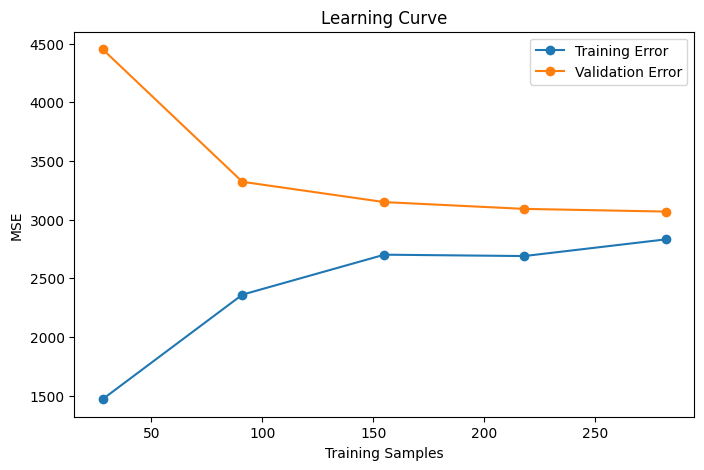

In [26]:
train_mean = -train_scores.mean(axis=1)
val_mean = -val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(
    train_sizes, train_mean, marker='o', label='Training Error'
)

plt.plot(
    train_sizes, val_mean, marker='o', label='Validation Error'
)

plt.xlabel('Training Samples')
plt.ylabel('MSE')
plt.title('Learning Curve')
plt.legend()
plt.show()

## 5. Visualizzazione con Data Reduction
Il dataset originale possiede uno spazio multidimensionale difficile da visualizzare. Applichiamo la **PCA (Principal Component Analysis)** per ridurre le feature a due sole dimensioni (PC1 e PC2), preservando la massima varianza possibile dei dati.
Successivamente, addestriamo il modello ottimizzato in questo spazio ridotto a 2D e utilizziamo `plt.contourf` (un grafico a contorni) per tracciare la superficie di regressione (il piano delle predizioni). Sovrapponendo i punti reali del Test Set, possiamo valutare visivamente come il modello interpreta la progressione della malattia nello spazio bidimensionale.

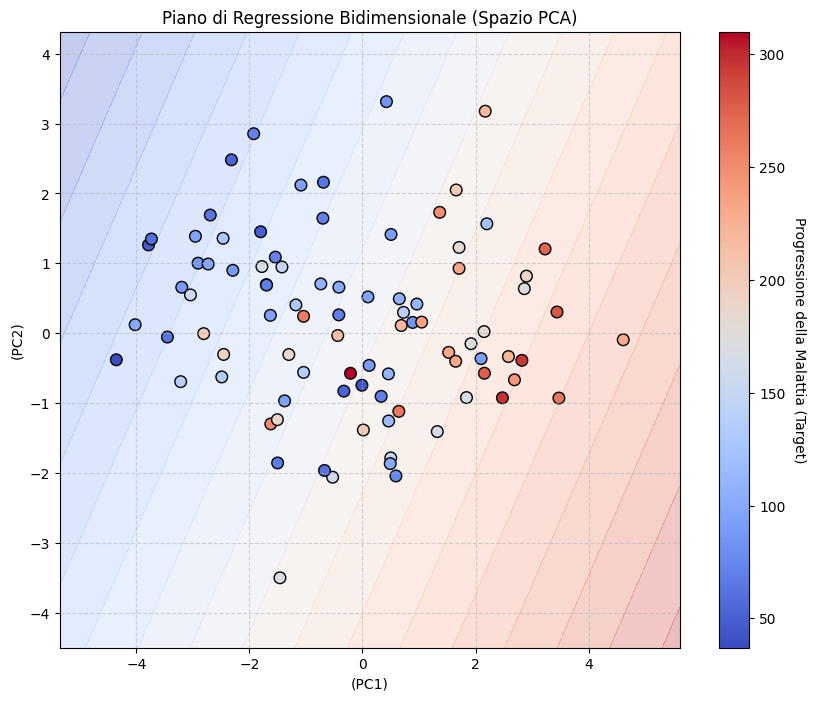

In [27]:
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled) 
x_test_pca = pca.transform(x_test_scaled)

best_ridge_pca = Ridge(alpha=grid.best_params_['alpha'])
best_ridge_pca.fit(x_train_pca, y_train)


plt.figure(figsize=(10, 8))

x_min, x_max = x_test_pca[:, 0].min() - 1, x_test_pca[:, 0].max() + 1
y_min, y_max = x_test_pca[:, 1].min() - 1, x_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

z = best_ridge_pca.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

plt.contourf(xx, yy, z, cmap='coolwarm', alpha=0.3, levels=20)

scatter = plt.scatter(x_test_pca[:, 0], x_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=70)

cbar = plt.colorbar(scatter)
cbar.set_label('Progressione della Malattia (Target)', rotation=270, labelpad=15)

plt.xlabel('(PC1)')
plt.ylabel('(PC2)')
plt.title('Piano di Regressione Bidimensionale (Spazio PCA)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()